In [1]:
from robust_plotter import *
from tests.indexador_2026 import *

import os


computador = "DESKTOP"

problema = 1
ymax = None
tmax = None


pc = indexar_device(computador)
dadosp = indexar_problema(problema)

# Path to your experiment folder
log_dir = os.path.join(pc.base_path, f"Problema {problema}", "Resultados")
out_dir = os.path.join(log_dir, "Graph")
os.makedirs(out_dir, exist_ok=True)

# define padrão de subpasta do diretório
def return_path(algo, index):
    return os.path.join(log_dir, algo, f"Conjunto {index}")

algos = ["GA", "PSO", "BO"]

salvar_algo = {algo: None for algo in algos}

plot = Plotter(log_dir)

Ativar salvamento:

In [2]:
plot.save_path(out_dir)
salvar_algo = {algo: os.path.join(plot.salvar_em, algo) for algo in algos}


POR ALGORITMO:

Convergência (todos os conjuntos):

In [11]:
for algo in algos:
    plot.plot_convergence_algorithm(algo, save=salvar_algo[algo], legenda=False)

Boxplot por parâmetro:

In [4]:
# for algo in algos:
#     for param in dadosp.keys:
#         plot.plot_parameter_boxplot(param, algo=[algo], key_to_name=dadosp.key_to_name, expected_value=dadosp.expected_values[param], search_space=dadosp.search_spaces, save=salvar_algo[algo])

Boxplot do erro (todos os parâmetros, um por conjunto):

In [5]:
for algo in algos:
    plot.plot_parameter_error_boxplot(expected_params=dadosp.expected_values, algo=algo, save=salvar_algo[algo])

TODOS OS ALGORITMOS

Filtrar melhores para as plotagens conjuntas:

In [3]:
# Filtrar conjuntos (boxplot)
filter_sets = {
    "GA": [1],
    "PSO": [1],
    "BO": [1]
}

logs_dir = {
    algo: return_path(algo, filter_sets[algo][0]) for algo in algos
}

Convergência x tempo:

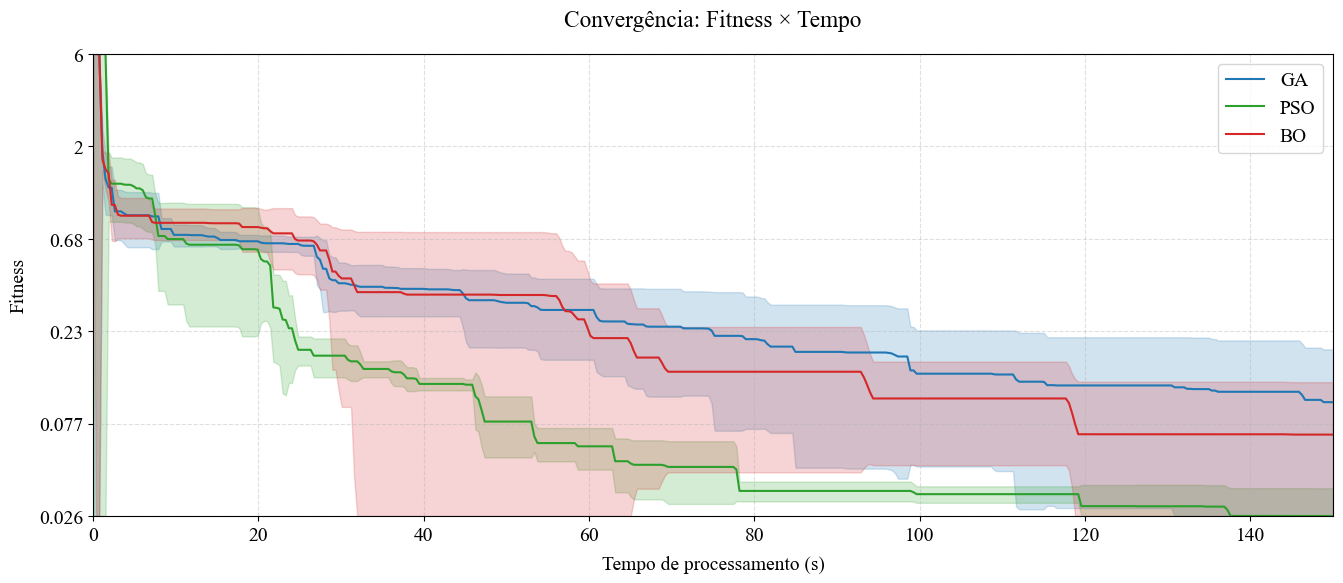

In [6]:
plot.plot_convergence_vs_time_logs(algos, logs_dir, ymax=6, tmax=150)

Boxplot comparativo por parâmetro:

In [8]:
for param in dadosp.keys:
    plot.plot_parameter_boxplot(param, algo=None, filter_sets=filter_sets, key_to_name=dadosp.key_to_name, expected_value=dadosp.expected_values[param], search_space=dadosp.search_spaces)

Compilar dados se necessário:

In [9]:
# # compilar dados na estrutura de compile.py
# from data.compile import compile_convergence_history
#
# for algo, sets in filter_sets.items():
#     algo_dir = os.path.join(log_dir, algo)
#
#     for set in sets:
#         conjunto_nome = f"Conjunto {set}"
#         set_dir = os.path.join(algo_dir, conjunto_nome)
#
#         compile_convergence_history(algo, dadosp.expected_values, set_dir, conjunto_nome)

Obsoletos:

In [10]:
# plot.plot_all_results(param_keys=dadosp.keys, key_to_name=dadosp.key_to_name, param_expected_values=dadosp.expected_values, param_search_space=dadosp.search_spaces, filter_sets=filter_sets)